# PageRank Importance Scores

This notebook computes PageRank importance scores for all nodes in the knowledge graph.

In [11]:
%load_ext kedro.ipython
%reload_kedro

The kedro.ipython extension is already loaded. To reload it, use:
  %reload_ext kedro.ipython


[02/28/26 13:48:36] INFO     Resolved project path as: /Users/an583/Documents/Zitnik_Lab/optimuskg. ]8;id=413972;file:///Users/an583/Documents/Zitnik_Lab/optimuskg/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=357432;file:///Users/an583/Documents/Zitnik_Lab/optimuskg/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py#180\180]8;;\
                             To set a different path, run '%reload_kedro <project_root>'                           

[02/28/26 13:48:37] INFO     Kedro project OptimusKG                                                ]8;id=961193;file:///Users/an583/Documents/Zitnik_Lab/optimuskg/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=340774;file:///Users/an583/Documents/Zitnik_Lab/optimuskg/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py#146\146]8;;\

                    INFO     Defined global variable 'context', 'session', 'catalog' and            ]8;id=17036;file:///Users/an583/Documents/Zitnik_Lab/optimuskg/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=869662;file:///Users/an583/Documents/Zitnik_Lab/optimuskg/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py#147\147]8;;\
                             'pipelines'                                                                           

                    INFO     Registered line magic 'run_viz'                                        ]8;id=795329;file:///Users/an583/Documents/Zitnik_Lab/optimuskg/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=541025;file:///Users/an583/Documents/Zitnik_Lab/optimuskg/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py#153\153]8;;\

In [12]:
import networkx as nx
import polars as pl
import matplotlib.pyplot as plt

In [13]:
# Load all edge DataFrames from the silver layer
silver_edges = catalog.filter(name_regex="silver.edges")
edge_dfs = [catalog.load(name) for name in silver_edges]
print(f"Loaded {len(edge_dfs)} edge types")

                    INFO     Loading data from silver.edges.protein_protein                    ]8;id=979554;file:///Users/an583/Documents/Zitnik_Lab/optimuskg/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=131291;file:///Users/an583/Documents/Zitnik_Lab/optimuskg/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py#1046\1046]8;;\
                             (ParquetDataset)...                                                                   

                    INFO     Loading data from silver.edges.exposure_molecular_function        ]8;id=352504;file:///Users/an583/Documents/Zitnik_Lab/optimuskg/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=834054;file:///Users/an583/Documents/Zitnik_Lab/optimuskg/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py#1046\1046]8;;\
                             (ParquetDataset)...                                                                   

                    INFO     Loading data from silver.edges.exposure_exposure                  ]8;id=275718;file:///Users/an583/Documents/Zitnik_Lab/optimuskg/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=528392;file:///Users/an583/Documents/Zitnik_Lab/optimuskg/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py#1046\1046]8;;\
                             (ParquetDataset)...                                                                   

                    INFO     Loading data from silver.edges.anatomy_protein                    ]8;id=186587;file:///Users/an583/Documents/Zitnik_Lab/optimuskg/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=275677;file:///Users/an583/Documents/Zitnik_Lab/optimuskg/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py#1046\1046]8;;\
                             (ParquetDataset)...                                                                   

                    INFO     Loading data from silver.edges.pathway_protein                    ]8;id=899082;file:///Users/an583/Documents/Zitnik_Lab/optimuskg/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=487914;file:///Users/an583/Documents/Zitnik_Lab/optimuskg/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py#1046\1046]8;;\
                             (ParquetDataset)...                                                                   

...

                    INFO     Loading data from silver.edges.anatomy_anatomy                    ]8;id=321382;file:///Users/an583/Documents/Zitnik_Lab/optimuskg/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=326660;file:///Users/an583/Documents/Zitnik_Lab/optimuskg/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py#1046\1046]8;;\
                             (ParquetDataset)...                                                                   

                    INFO     Loading data from silver.edges.disease_disease                    ]8;id=835798;file:///Users/an583/Documents/Zitnik_Lab/optimuskg/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=219679;file:///Users/an583/Documents/Zitnik_Lab/optimuskg/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py#1046\1046]8;;\
                             (ParquetDataset)...                                                                   

                    INFO     Loading data from silver.edges.drug_phenotype (ParquetDataset)... ]8;id=234342;file:///Users/an583/Documents/Zitnik_Lab/optimuskg/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=546128;file:///Users/an583/Documents/Zitnik_Lab/optimuskg/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py#1046\1046]8;;\

                    INFO     Loading data from silver.edges.exposure_cellular_component        ]8;id=810532;file:///Users/an583/Documents/Zitnik_Lab/optimuskg/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=154576;file:///Users/an583/Documents/Zitnik_Lab/optimuskg/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py#1046\1046]8;;\
                             (ParquetDataset)...                                                                   

Loaded 26 edge types


In [14]:
# Load all node DataFrames to get node metadata (id -> label, name mapping)
silver_nodes = catalog.filter(name_regex="silver.nodes")
node_dfs = [catalog.load(name) for name in silver_nodes]

# Create a lookup DataFrame mapping node_id to label and name
node_lookup = pl.concat([
    df.select(
        "id",
        "label",
        pl.col("properties").struct.field("name").alias("name")
    )
    for df in node_dfs
])
print(f"Loaded {node_lookup.height} total nodes across {len(node_dfs)} node types")

                    INFO     Loading data from silver.nodes.pathway (ParquetDataset)...        ]8;id=338064;file:///Users/an583/Documents/Zitnik_Lab/optimuskg/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=867439;file:///Users/an583/Documents/Zitnik_Lab/optimuskg/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py#1046\1046]8;;\

                    INFO     Loading data from silver.nodes.gene (ParquetDataset)...           ]8;id=478012;file:///Users/an583/Documents/Zitnik_Lab/optimuskg/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=980638;file:///Users/an583/Documents/Zitnik_Lab/optimuskg/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py#1046\1046]8;;\

[02/28/26 13:48:39] INFO     Loading data from silver.nodes.anatomy (ParquetDataset)...        ]8;id=57401;file:///Users/an583/Documents/Zitnik_Lab/optimuskg/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=751893;file:///Users/an583/Documents/Zitnik_Lab/optimuskg/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py#1046\1046]8;;\

                    INFO     Loading data from silver.nodes.disease (ParquetDataset)...        ]8;id=800386;file:///Users/an583/Documents/Zitnik_Lab/optimuskg/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=410505;file:///Users/an583/Documents/Zitnik_Lab/optimuskg/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py#1046\1046]8;;\

                    INFO     Loading data from silver.nodes.drug (ParquetDataset)...           ]8;id=284194;file:///Users/an583/Documents/Zitnik_Lab/optimuskg/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=402511;file:///Users/an583/Documents/Zitnik_Lab/optimuskg/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py#1046\1046]8;;\

...

                    INFO     Loading data from silver.nodes.cellular_component                 ]8;id=623355;file:///Users/an583/Documents/Zitnik_Lab/optimuskg/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=150488;file:///Users/an583/Documents/Zitnik_Lab/optimuskg/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py#1046\1046]8;;\
                             (ParquetDataset)...                                                                   

                    INFO     Loading data from silver.nodes.phenotype (ParquetDataset)...      ]8;id=472814;file:///Users/an583/Documents/Zitnik_Lab/optimuskg/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=318809;file:///Users/an583/Documents/Zitnik_Lab/optimuskg/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py#1046\1046]8;;\

                    INFO     Loading data from silver.nodes.molecular_function                 ]8;id=182548;file:///Users/an583/Documents/Zitnik_Lab/optimuskg/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=158400;file:///Users/an583/Documents/Zitnik_Lab/optimuskg/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py#1046\1046]8;;\
                             (ParquetDataset)...                                                                   

                    INFO     Loading data from silver.nodes.exposure (ParquetDataset)...       ]8;id=897374;file:///Users/an583/Documents/Zitnik_Lab/optimuskg/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=615389;file:///Users/an583/Documents/Zitnik_Lab/optimuskg/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py#1046\1046]8;;\

Loaded 189993 total nodes across 10 node types


In [15]:
# Build an undirected NetworkX graph from all edges
G = nx.Graph()
for df in edge_dfs:
    edge_pairs = df.select("from", "to").iter_rows()
    G.add_edges_from(edge_pairs)

print(f"Graph has {G.number_of_nodes():,} nodes and {G.number_of_edges():,} edges")

Graph has 189,434 nodes and 20,490,144 edges


In [16]:
# Compute PageRank scores (alpha=0.85 is the default damping factor)
pagerank_scores = nx.pagerank(G, alpha=0.85)
print(f"Computed PageRank for {len(pagerank_scores):,} nodes")

Computed PageRank for 189,434 nodes


In [17]:
# Convert to DataFrame and join with node metadata
pagerank_df = pl.DataFrame({
    "id": list(pagerank_scores.keys()),
    "pagerank": list(pagerank_scores.values())
})

# Join with node lookup to get node types and names
pagerank_df = pagerank_df.join(node_lookup, on="id", how="left")

# Sort by PageRank score descending and add rank
pagerank_df = (
    pagerank_df
    .sort("pagerank", descending=True)
    .with_row_index("rank", offset=1)
    .select("rank", "id", "label", "name", "pagerank")
)

In [18]:
# Display top 10 nodes by PageRank score
pagerank_df.head(10)

rank,id,label,name,pagerank
u32,str,str,str,f64
1,"""PATO_0000070""","""DIS""","""amount""",0.006259
2,"""EFO_0004747""","""DIS""","""protein measurement""",0.003493
3,"""UBERON_0000178""","""ANA""","""blood""",0.000961
4,"""UBERON_0004533""","""ANA""","""left testis""",0.00095
5,"""UBERON_0001511""","""ANA""","""skin of leg""",0.000902
6,"""UBERON_0001388""","""ANA""","""gastrocnemius""",0.000879
7,"""UBERON_0035833""","""ANA""","""lower esophagus muscularis lay…",0.000877
8,"""UBERON_0001323""","""ANA""","""tibial nerve""",0.000876
9,"""UBERON_0002810""","""ANA""","""right frontal lobe""",0.000874


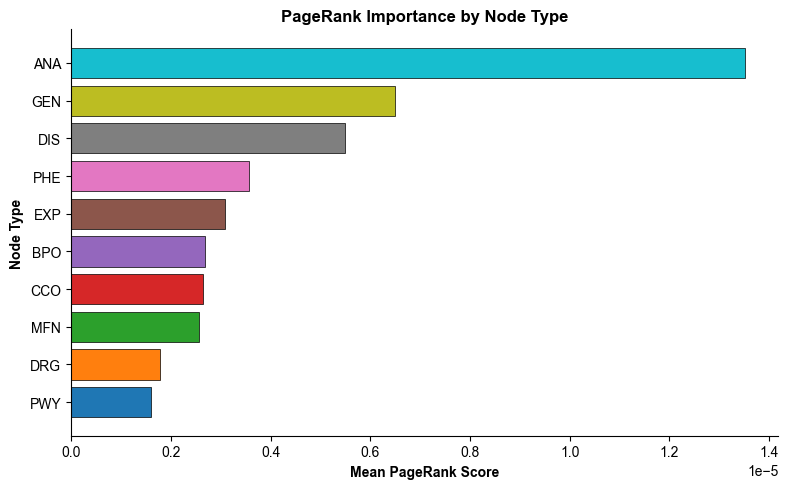

label,mean_pagerank,count
str,f64,u32
"""ANA""",0.000014,14624
"""GEN""",0.000006,61306
"""DIS""",0.000006,36992
"""PHE""",0.000004,19341
"""EXP""",0.000003,881
"""BPO""",0.000003,25754
"""CCO""",0.000003,4052
"""MFN""",0.000003,10161
"""DRG""",0.000002,14077


In [19]:
# Visualize mean PageRank by node type
pagerank_by_type = (
    pagerank_df
    .group_by("label")
    .agg(
        pl.col("pagerank").mean().alias("mean_pagerank"),
        pl.col("pagerank").count().alias("count")
    )
    .sort("mean_pagerank", descending=True)
)

# Create bar chart
fig, ax = plt.subplots(figsize=(8, 5))

labels = pagerank_by_type["label"].to_list()[::-1]
values = pagerank_by_type["mean_pagerank"].to_list()[::-1]
colors = plt.cm.tab10.colors[:len(pagerank_by_type)]

ax.barh(labels, values, color=colors, edgecolor="black", linewidth=0.5)

ax.set_xlabel("Mean PageRank Score", fontweight="bold")
ax.set_ylabel("Node Type", fontweight="bold")
ax.set_title("PageRank Importance by Node Type", fontweight="bold")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

# Display the data
pagerank_by_type